## Health Insurance Underwriting & Pricing Analytics

In [1]:
# ============================================================
# 1. Setup & Libraries
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set(style="whitegrid")


In [2]:
# ============================================================
# 2. Simulated Health Insurance Underwriting Dataset
# ============================================================

np.random.seed(42)

n = 5000

df = pd.DataFrame({
    "age": np.random.randint(18, 80, n),
    "bmi": np.random.normal(27, 5, n).round(1),
    "smoker": np.random.choice([0,1], n, p=[0.8, 0.2]),
    "chronic_conditions": np.random.poisson(0.6, n),
    "gender": np.random.choice(["M","F"], n),
    "region": np.random.choice(["North","South","East","West"], n),
})

# Claims cost model (synthetic)
df["claims_cost"] = (
    df["age"]*12 +
    df["bmi"]*15 +
    df["smoker"]*2000 +
    df["chronic_conditions"]*800 +
    np.random.normal(0, 500, n)
).clip(lower=0)

df.head()


,age,bmi,smoker,chronic_conditions,gender,region,claims_cost
0,56,11.9,0,0,M,East,802.010000
1,69,27.9,1,0,F,East,3223.745663
2,46,36.0,0,1,M,East,1520.168451
3,32,33.2,0,0,F,North,1022.834285
4,60,28.0,0,0,F,West,1348.900169


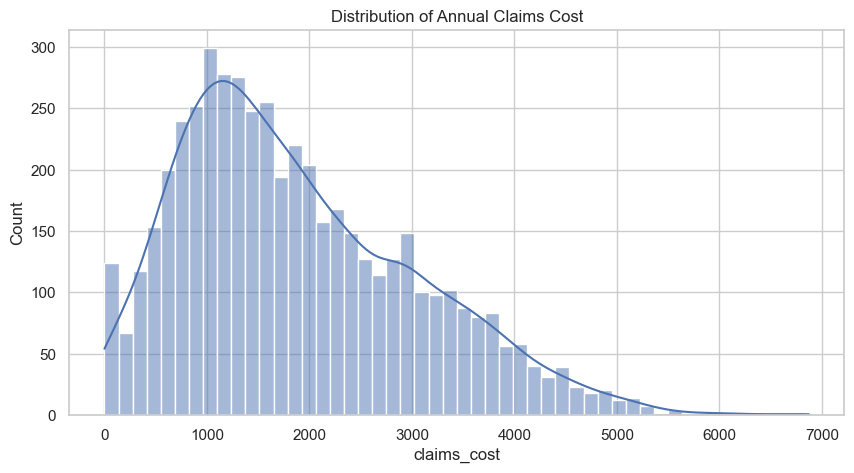

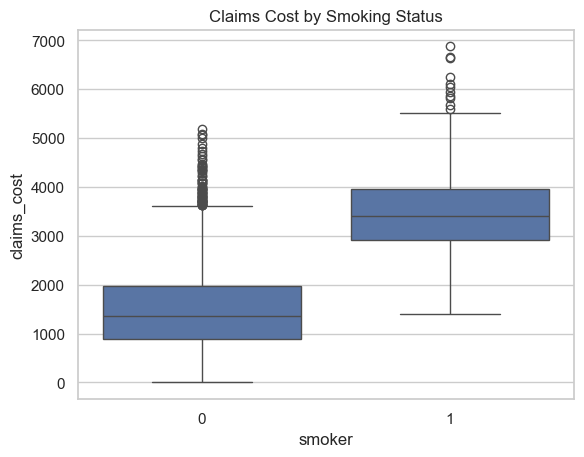

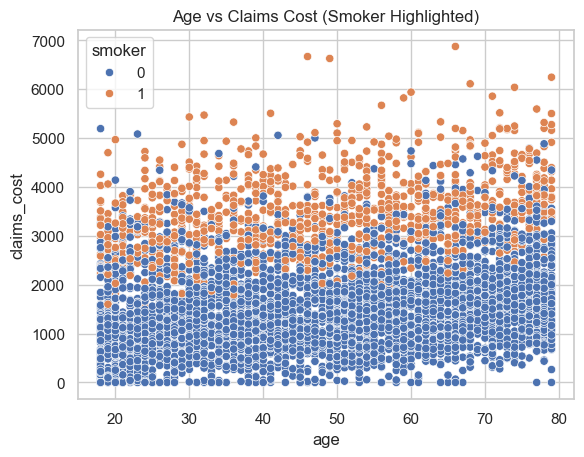

In [3]:
# ============================================================
# 3. Exploratory Underwriting Insights
# ============================================================

plt.figure(figsize=(10,5))
sns.histplot(df["claims_cost"], bins=50, kde=True)
plt.title("Distribution of Annual Claims Cost")
plt.show()

sns.boxplot(x="smoker", y="claims_cost", data=df)
plt.title("Claims Cost by Smoking Status")
plt.show()

sns.scatterplot(x="age", y="claims_cost", hue="smoker", data=df)
plt.title("Age vs Claims Cost (Smoker Highlighted)")
plt.show()


In [4]:
# ============================================================
# 4. Risk Segmentation
# ============================================================

df["risk_score"] = (
    df["age"]*0.02 +
    df["bmi"]*0.03 +
    df["smoker"]*1.5 +
    df["chronic_conditions"]*0.8
)

df["risk_band"] = pd.qcut(df["risk_score"], q=4, labels=["Low","Medium","High","Very High"])

df["risk_band"].value_counts()


risk_band
Low          1252
High         1252
Medium       1248
Very High    1248
Name: count, dtype: int64

In [5]:
# ============================================================
# 5. Claims Cost Prediction Model - Using Random Forest
# ============================================================

X = df[["age","bmi","smoker","chronic_conditions"]]
y = df["claims_cost"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R²:", r2_score(y_test, preds))


MAE: 444.18856128170694
R²: 0.7640341837343088


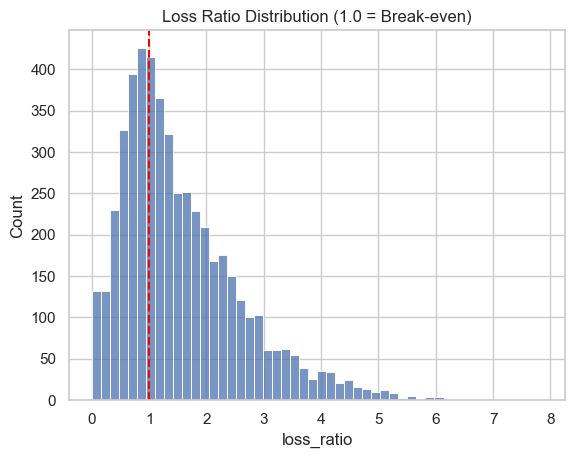

C:\Users\V110User\AppData\Local\Temp\ipykernel_1200\3020899511.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("risk_band")["loss_ratio"].mean()


risk_band
Low          0.842908
Medium       1.082202
High         1.715152
Very High    2.596378
Name: loss_ratio, dtype: float64

In [6]:
# ============================================================
# 6. Pricing Adequacy Check
# ============================================================

# Assume current premium is based on simple age-based pricing
df["current_premium"] = df["age"] * 20 + 300

df["loss_ratio"] = df["claims_cost"] / df["current_premium"]

sns.histplot(df["loss_ratio"], bins=50)
plt.axvline(1.0, color="red", linestyle="--")
plt.title("Loss Ratio Distribution (1.0 = Break-even)")
plt.show()

df.groupby("risk_band")["loss_ratio"].mean()


In [7]:
# ============================================================
# 7. Scenario Testing: New Pricing Strategy
# ============================================================

df["proposed_premium"] = (
    300 +
    df["risk_score"]*150 +
    df["chronic_conditions"]*50
)

df["new_loss_ratio"] = df["claims_cost"] / df["proposed_premium"]

df[["loss_ratio","new_loss_ratio"]].describe()


,loss_ratio,new_loss_ratio
count,5000.000000,5000.000000
mean,1.558712,2.460007
std,1.053829,1.097865
min,0.000000,0.000000
25%,0.796094,1.679074
50%,1.299557,2.448717
75%,2.104709,3.262189
max,7.867005,5.595243


In [8]:
# ============================================================
# 8. Portfolio Impact Summary
# ============================================================

summary = df.groupby("risk_band")[["claims_cost","current_premium","proposed_premium","loss_ratio","new_loss_ratio"]].mean()
summary


C:\Users\V110User\AppData\Local\Temp\ipykernel_1200\245150363.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("risk_band")[["claims_cost","current_premium","proposed_premium","loss_ratio","new_loss_ratio"]].mean()


,claims_cost,current_premium,proposed_premium,loss_ratio,new_loss_ratio
risk_band,,,,,
Low,837.079331,1021.150160,526.706789,0.842908,1.580512
Medium,1299.348193,1352.179487,630.842027,1.082202,2.051667
High,2020.043036,1325.894569,756.622085,1.715152,2.666605
Very High,3386.388339,1405.881410,953.842268,2.596378,3.543403


In [9]:
# ============================================================
# 9. Export Results (Optional)
# ============================================================

df.to_csv("underwriting_analysis_output.csv", index=False)
